In [4]:
import pandas as pd
df=pd.read_csv("../data/ks-projects-201801.csv", encoding="latin-1")
df.shape

(378661, 15)

In [6]:
df.columns.tolist()


['ID',
 'name',
 'category',
 'main_category',
 'currency',
 'deadline',
 'goal',
 'launched',
 'pledged',
 'state',
 'backers',
 'country',
 'usd pledged',
 'usd_pledged_real',
 'usd_goal_real']

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 378661 entries, 0 to 378660
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID                378661 non-null  int64  
 1   name              378657 non-null  str    
 2   category          378661 non-null  str    
 3   main_category     378661 non-null  str    
 4   currency          378661 non-null  str    
 5   deadline          378661 non-null  str    
 6   goal              378661 non-null  float64
 7   launched          378661 non-null  str    
 8   pledged           378661 non-null  float64
 9   state             378661 non-null  str    
 10  backers           378661 non-null  int64  
 11  country           378661 non-null  str    
 12  usd pledged       374864 non-null  float64
 13  usd_pledged_real  378661 non-null  float64
 14  usd_goal_real     378661 non-null  float64
dtypes: float64(5), int64(2), str(8)
memory usage: 43.3 MB


In [8]:
df.head()

,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,usd_pledged_real,usd_goal_real
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09,1000.0,2015-08-11 12:12:28,0.0,failed,0,GB,0.0,0.0,1533.95
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017-11-01,30000.0,2017-09-02 04:43:57,2421.0,failed,15,US,100.0,2421.0,30000.00
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26,45000.0,2013-01-12 00:20:50,220.0,failed,3,US,220.0,220.0,45000.00
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16,5000.0,2012-03-17 03:24:11,1.0,failed,1,US,1.0,1.0,5000.00
4,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29,19500.0,2015-07-04 08:35:03,1283.0,canceled,14,US,1283.0,1283.0,19500.00


In [9]:
df["state"].value_counts()

state
failed        197719
successful    133956
canceled       38779
undefined       3562
live            2799
suspended       1846
Name: count, dtype: int64

In [10]:
df["state"].value_counts(normalize=True).round(3)*100

state
failed        52.2
successful    35.4
canceled      10.2
undefined      0.9
live           0.7
suspended      0.5
Name: proportion, dtype: float64

In [11]:
df[["goal", "pledged", "backers", "usd_goal_real", "usd_pledged_real"]].describe()

,goal,pledged,backers,usd_goal_real,usd_pledged_real
count,3.786610e+05,3.786610e+05,378661.000000,3.786610e+05,3.786610e+05
mean,4.908079e+04,9.682979e+03,105.617476,4.545440e+04,9.058924e+03
std,1.183391e+06,9.563601e+04,907.185035,1.152950e+06,9.097334e+04
min,1.000000e-02,0.000000e+00,0.000000,1.000000e-02,0.000000e+00
25%,2.000000e+03,3.000000e+01,2.000000,2.000000e+03,3.100000e+01
50%,5.200000e+03,6.200000e+02,12.000000,5.500000e+03,6.243300e+02
75%,1.600000e+04,4.076000e+03,56.000000,1.550000e+04,4.050000e+03
max,1.000000e+08,2.033899e+07,219382.000000,1.663614e+08,2.033899e+07


In [12]:
df.isnull().sum()[df.isnull().sum()>0]

name              4
usd pledged    3797
dtype: int64

In [13]:
print("Zero or negative goal:", (df["usd_goal_real"]<=0).sum())
print("Negative backers:", (df["backers"]<0).sum())

Zero or negative goal: 0
Negative backers: 0


In [14]:
df_clean=df[df["state"].isin(["successful", "failed"])].copy()
df_clean["target"]=(df_clean["state"]=="successful").astype(int)
df_clean["target"].value_counts(normalize=True).round(3)*100

target
0    59.6
1    40.4
Name: proportion, dtype: float64

In [15]:
df_clean["main_category"].unique()
df_clean["category"].unique()
df_clean["country"].unique()
df_clean["currency"].unique()

<StringArray>
['GBP', 'USD', 'CAD', 'AUD', 'NOK', 'EUR', 'MXN', 'SEK', 'NZD', 'CHF', 'DKK',
 'HKD', 'SGD', 'JPY']
Length: 14, dtype: str

In [16]:
df_clean["country"].unique()

<StringArray>
[  'GB',   'US',   'CA',   'AU',   'NO',   'IT',   'DE',   'IE',   'MX',
   'ES',   'SE',   'FR',   'NZ',   'CH',   'AT',   'BE',   'DK',   'HK',
   'NL',   'LU',   'SG', 'N,0"',   'JP']
Length: 23, dtype: str

In [17]:
(df_clean["country"]=='N,0"').sum()

np.int64(210)

In [18]:
df_clean=df_clean[df_clean["country"]!='N,0"'].copy()
df_clean.shape

(331465, 16)

In [19]:
df_clean["launched"]=pd.to_datetime(df_clean["launched"])
df_clean["deadline"]=pd.to_datetime(df_clean["deadline"])
df_clean[["launched", "deadline"]].dtypes

launched    datetime64[us]
deadline    datetime64[us]
dtype: object

In [20]:
df_clean["launched"].min()

Timestamp('2009-04-21 21:02:48')

In [21]:
df_clean["launched"].max()
df_clean["deadline"].max()

Timestamp('2018-01-02 00:00:00')

In [22]:
df_clean.shape
df_clean.isnull().sum()[df_clean.isnull().sum()>0]

name    3
dtype: int64

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

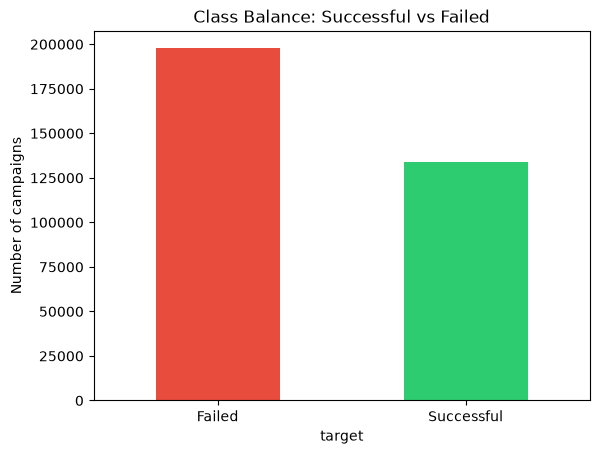

In [24]:
df_clean["target"].value_counts().plot(kind="bar", color=["#e74c3c", "#2ecc71"])
plt.xticks([0,1], ["Failed", "Successful"], rotation=0)
plt.ylabel("Number of campaigns")
plt.title("Class Balance: Successful vs Failed")
plt.show()

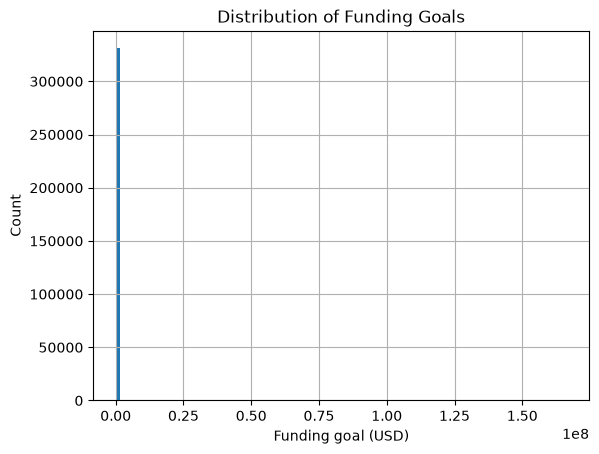

In [26]:
df_clean["usd_goal_real"].hist(bins=100)
plt.xlabel("Funding goal (USD)")
plt.ylabel("Count")
plt.title("Distribution of Funding Goals")
plt.show()

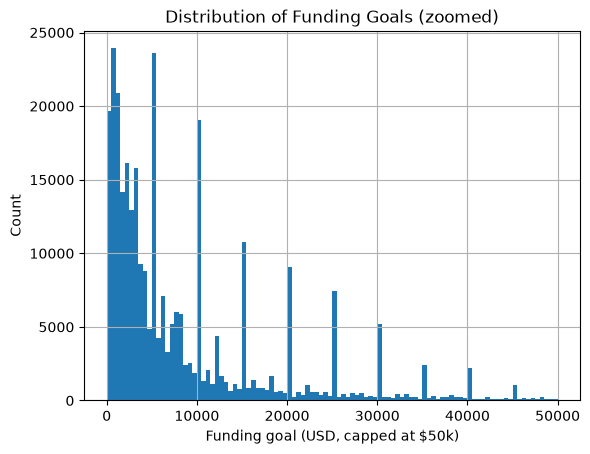

In [27]:
df_clean[df_clean["usd_goal_real"] < 50000]["usd_goal_real"].hist(bins=100)
plt.xlabel("Funding goal (USD, capped at $50k)")
plt.ylabel("Count")
plt.title("Distribution of Funding Goals (zoomed)")
plt.show()

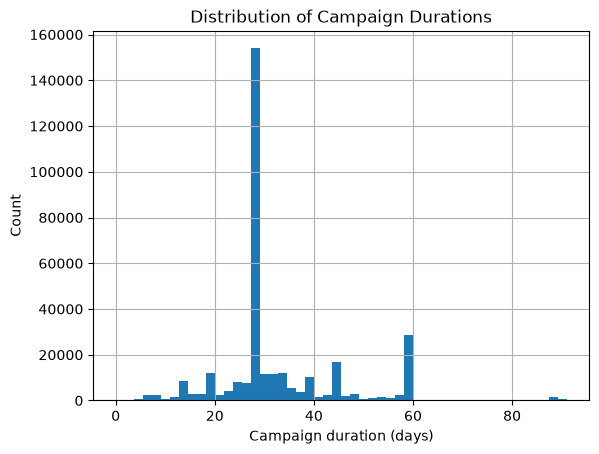

In [28]:
df_clean["duration_days"]=(df_clean["deadline"] - df_clean["launched"]).dt.days
df_clean["duration_days"].hist(bins=50)
plt.xlabel("Campaign duration (days)")
plt.ylabel("Count")
plt.title("Distribution of Campaign Durations")
plt.show()

In [29]:
df_clean["duration_days"].describe()

count    331465.000000
mean         32.955950
std          12.714114
min           0.000000
25%          29.000000
50%          29.000000
75%          35.000000
max          91.000000
Name: duration_days, dtype: float64

In [30]:
(df_clean["duration_days"]>60).sum()
(df_clean["duration_days"]<1).sum()

np.int64(92)

In [31]:
(df_clean["duration_days"]<1).sum()

np.int64(92)

In [32]:
df_clean=df_clean[(df_clean["duration_days"] >=1) & (df_clean["duration_days"] <=60)].copy()
df_clean.shape

(327237, 17)

In [33]:
print("Over 60 days:", (df_clean["duration_days"] >60).sum())
print("Under 1 day:", (df_clean["duration_days"] <1).sum())

Over 60 days: 0
Under 1 day: 0
